<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install opendatasets

In [6]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadtegarbijanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:01<00:00, 98.2MB/s]


## **Mengambil data kaggle**
Pada bagian ini, digunakan library opendatasets untuk mengambil data dari website kaggle, ini digunakan agar kita tidak perlu mendownload file kaggle nya. Ini membuat pengambilan data nya lebih efisien.

In [7]:
import os
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## **Import Library**
Melakukan import terhadap library yang digunakan untuk menyelesaikan tahap percobaan 2 projek ini.

In [8]:
data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in sorted(files):
            if class_counters[folder_aktif] >= 300:
                break

            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:

                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                    img_gray = cv.resize(img_gray, (256, 256))

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")

Sukses membaca data mentah! Total data awal: 600 gambar.


## **Data Loading**
Pada bagian ini, dilakukan pembacaan data dari file kaggle yang telah diambil pada bagian sebelumnya. Pada bagian ini juga digunakan variabel data sebagai tempat menyimpan data yang akan digunakan. Data yang digunakan untuk percobaan ini adalah 300 data saja, jadi setiap kelas yang akan dianalisis akan menggunakan 300 data. Pada bagian ini setiap data sudah diubah menjadi grayscale dan di resize dengan ukuran 256x256 ini, hal ini dilakukan karena processing yang di lakukan pada percobaan 2 ini menggunakan preprocessing grayscale dan resize. Dan agar citra yang di proses memiliki ukuran yang sama. Pada data loading ini juga digunakan sorted pada perulangan nya, agar citra yang di proses atau dianalisis itu akan terurut dari data 1 hingga seterusnya yang sesuai dengan isi dari sub folder atau kelasnya. Preprocessing yang dilakukan pada tahap ini dibuat agar kita tidak perlu melakukan kembali preprocessing berikut pada tahap data processing.

In [9]:
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} gambar")
print(f"Total data: {len(data)} gambar")

Kelas glioma: 300 gambar
Kelas notumor: 300 gambar
Total data: 600 gambar


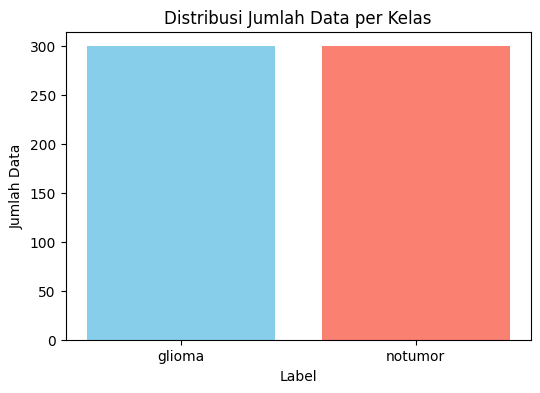

In [10]:
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['skyblue','salmon'])
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.show()

## Data Understanding

Block kode ini berfungsi untuk memverifikasi dan menampilkan distribusi jumlah data pada setiap kelas tumor otak secara dinamis dari array labels menggunakan fungsi np.unique(..., return_counts=True). Melalui perulangan zip(unique, counts), sistem akan memasangkan setiap nama kelas yang unik dengan total sampelnya untuk memastikan bahwa dataset yang digunakan kelompok kalian sudah seimbang (balanced) pas 300 gambar per kelas, sebelum akhirnya menampilkan total keseluruhan data (len(data)) yang siap masuk ke tahap ekstraksi fitur tekstur GLCM.

Block kode dibawah ini berfungsi untuk menampilkan visualisasi grafis berupa diagram batang (bar chart) dari distribusi jumlah data per kelas menggunakan pustaka matplotlib.pyplot. Berdasarkan data unik kelas dan jumlahnya yang telah dihitung sebelumnya (unique dan counts), diagram ini akan menggambarkan perbandingan kuantitas antar kelas secara visual dengan pewarnaan kustom (skyblue dan salmon), sehingga memudahkan dalam memverifikasi keseimbangan proporsi dataset sebelum melangkah ke proses analisis tekstur lebih lanjut.

In [11]:
def median(image, rowkernel, columnkernel):
    row, column = int(rowkernel/2), int(columnkernel/2)
    image_pad = np.pad(image, [(row, row), (column, column)], mode="edge")
    result = np.zeros(image.shape)

    for i in range(row, image.shape[0] + row):
        for j in range(column, image.shape[1] + column):
            submatrix = image_pad[i-row:i+row+1, j-column:j+column+1]
            result[i-row, j-column] = np.median(submatrix)

    return result.astype(np.uint8)

## Fungsi Median Filter

Pada bagian ini dibuat fungsi untuk membuat median filter secara manual yang dimana ini akan digunakan pada tahap percobaan. Dan RowKernel dan ColummnKernel akan diisi sendiri oleh pengguna untuk mendapatkan kernel yang diinginkan


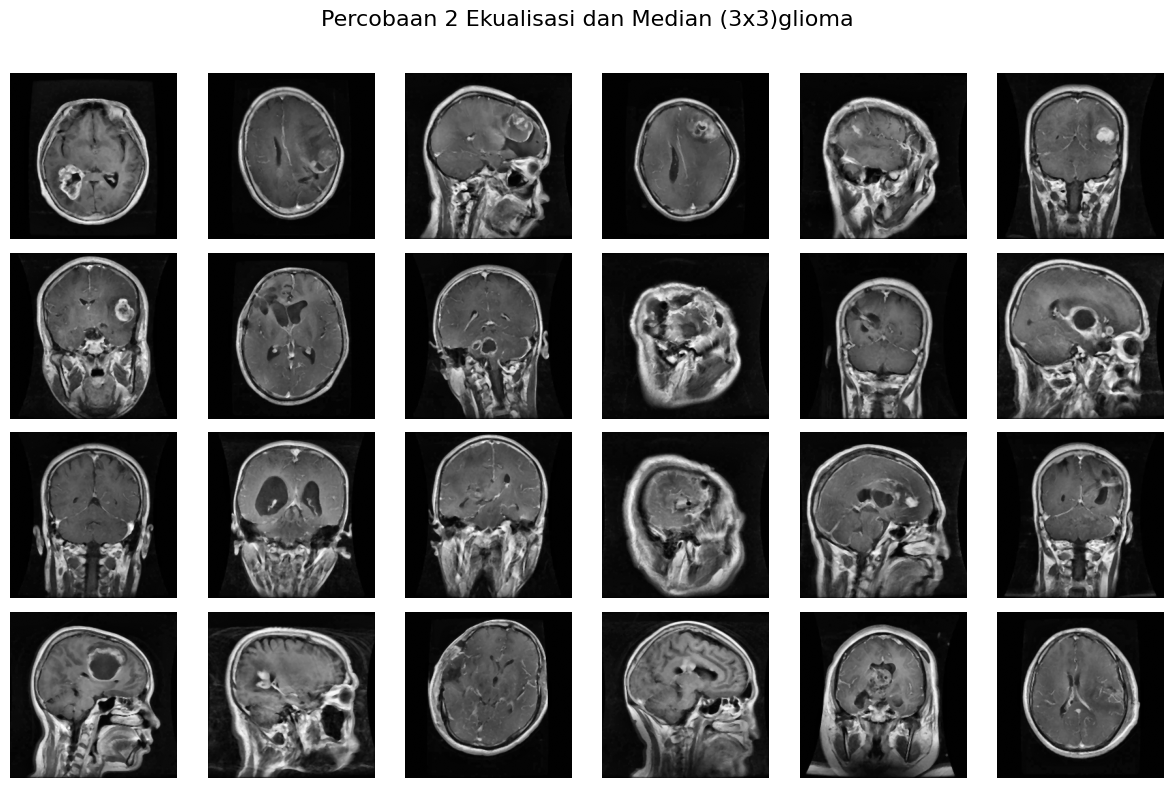

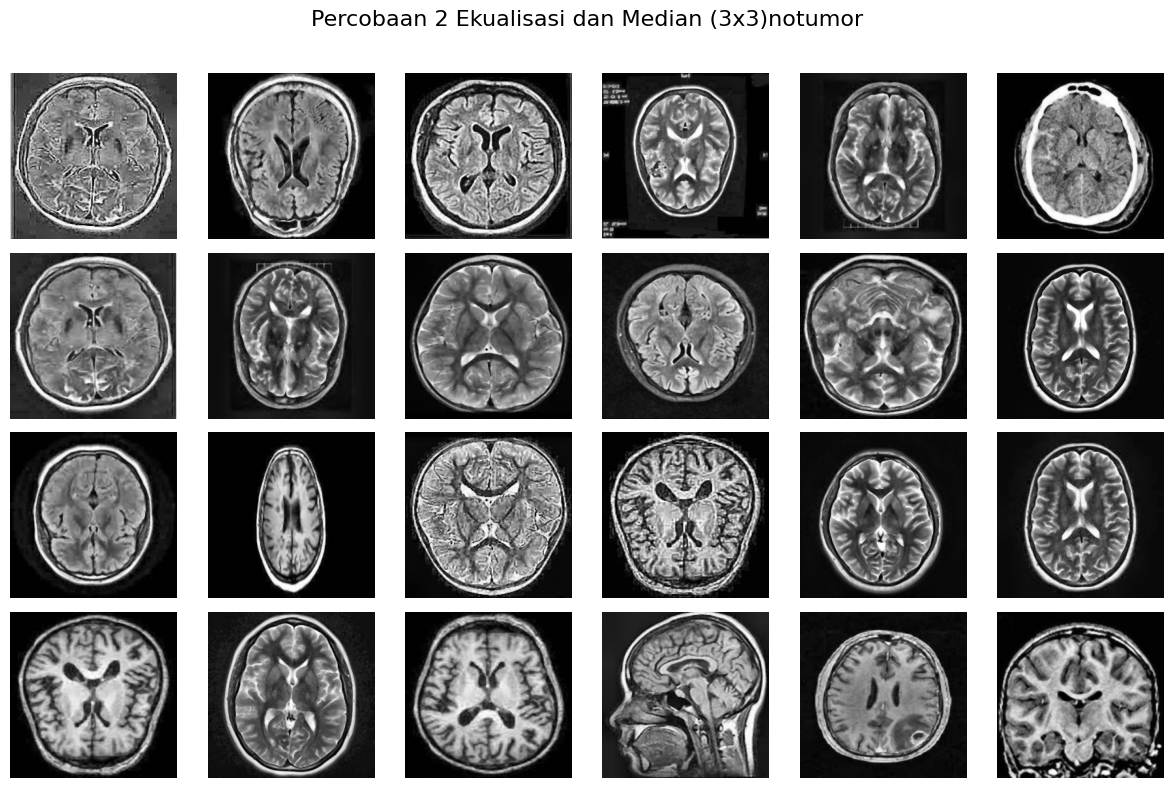

In [13]:
def percobaan2(img):
    img = img.astype(np.uint8)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(img)
    img_equal = median(equalized, 3, 3)
    return img_equal

dataPreprocessed = [percobaan2(img_gray) for img_gray in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]

    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 2 Ekualisasi dan Median (3x3){label}', fontsize=16)

    for k in range(24):
        plt.subplot(4, 6, k + 1)
        plt.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

## PERCOBAAN 2 (CLAHE, MEDIAN FILTER)
Pada bagian ini dilakukan percobaan clahe dan median filter untuk melakukan klasifikasi terhadap citra yang merupakan tumor otak dan otak yang sehat. Tahap CLAHE dilakukan untuk mendapatkan hasil citra yang lebih tajam yang dimana hal ini sebenernya dapat dilakukan menggunakan fungsi ekualisasi biasa, namun hasil didapatkan saat menggunakan ekualisasi biasa kurang bagus yang dimana noise yang dihasilkan lebih banyak. Sebelum penerapan CLAHE, citra terlebih dahulu diubah tipe data nya dalam bentuk uint8, hal ini bertujuan karena pengaplikasian CLAHE hanya bisa memproses nilai pasti seperti uint8. CLAHE dengan parameter clipLimit=2.0 yang berfungsi membatasi amplifikasi kontras agar tidak menghasilkan noise berlebih, dan tileGridSize=(8,8) yang membagi gambar menjadi grid 8x8 piksel untuk diproses secara lokal, grid ini biasa digunakan biasanya untuk tahap analisis MRI. Penggunaan CLAHE ini membuat hasil ekualisasi menjadi lebih bersih dan tajam. Setelah penggunaan CLAHE, diterapkan median filter 3x3 untuk mendapatkan hasil noise yang lebih kecil, hal ini membuat hasil CLAHE tadi yang sudah lumayan tajam dengan noise yang sedikit dapat menghasilkan citra yang lebih tajam lagi dan noise yang lebih sedikit lagi.

In [14]:
for i in range(len(dataPreprocessed)):
    dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8)

print(len(dataPreprocessed))

600


## **Pengubahan tipe data**
Pada bagian ini, setiap data yang dihasilkan dari percobaan 2 ini akan diubah tipe data nya menjadi uint8 dengan rentang skala 0 - 255. Pengubahan tipe data ini dilakukan agar data citra dapat diterima secara valid oleh fungsi ekstraksi fitur tekstur GLCM.

In [15]:
def glcm(img, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(img, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [16]:

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [17]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [18]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [19]:

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)


for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)


In [20]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
from google.colab import files
files.download('hasil_ekstraksi_2.csv')

display(hasilEkstrak)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,no-0001.jpg,notumor,1096.626011,1672.206398,879.017172,1683.805813,0.316346,0.221282,0.329395,0.219144,...,0.000776,0.000447,0.027494,0.021227,0.027857,0.021146,0.821168,0.727560,0.858079,0.725669
1,no-0002.jpg,notumor,474.728860,695.171411,299.083778,696.487889,0.452307,0.396895,0.460521,0.399220,...,0.064012,0.061456,0.249824,0.247376,0.253006,0.247903,0.954440,0.933259,0.971301,0.933132
2,no-0003.jpg,notumor,721.455162,1182.076647,617.575996,1185.490088,0.339676,0.266488,0.347147,0.267089,...,0.012042,0.011188,0.109303,0.105752,0.109737,0.105773,0.940046,0.901760,0.948660,0.901475
3,no-0004.jpg,notumor,414.885692,818.976640,499.668490,803.893672,0.539136,0.453720,0.530539,0.454728,...,0.048693,0.045799,0.220828,0.214176,0.220665,0.214007,0.957046,0.914559,0.947806,0.916133
4,no-0005.jpg,notumor,240.759161,373.235063,171.402145,368.247105,0.500465,0.449801,0.543244,0.451400,...,0.019899,0.015417,0.128962,0.124136,0.141064,0.124166,0.960181,0.938409,0.971678,0.939232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,gl-0296.jpg,glioma,132.743811,200.436878,90.353278,202.350173,0.734552,0.682673,0.735745,0.682385,...,0.119501,0.113229,0.344717,0.336479,0.345690,0.336495,0.969928,0.954681,0.979531,0.954249
596,gl-0297.jpg,glioma,115.099724,196.907436,108.866973,206.421469,0.644233,0.591554,0.647892,0.592509,...,0.109405,0.104939,0.330226,0.323943,0.330764,0.323943,0.977889,0.962222,0.979086,0.960397
597,gl-0298.jpg,glioma,129.163940,207.866021,110.964400,223.759354,0.581319,0.521610,0.583562,0.514728,...,0.030747,0.027117,0.180600,0.165882,0.175348,0.164673,0.983538,0.973546,0.985855,0.971523
598,gl-0299.jpg,glioma,69.539522,105.127997,46.509743,108.802307,0.681661,0.631998,0.687510,0.627303,...,0.070026,0.065050,0.264004,0.255535,0.264625,0.255049,0.984271,0.976278,0.989483,0.975449


## Ekstraksi Fitur GLCM
Pada bagian ini, dilakukan pengekstraksian fitur pada hasil percobaan 2 ini. Dari ekstraksi fitur ini didapatkan hasil contrast, homogeinity, dissimilarity, entropy, ASM, energy, dan correlation dari sudut 0, 45, 90 dan 135. Ekstraksi fitur GLCM ini berfungsi untuk menghitung dan mengubah karakteristik visual tersebut menjadi angka-angka statistik (nilai numerik) yang bisa dipahami oleh komputer. Hal ini untuk membuat komputer dapat memahami perbedaan antara citra yang memiliki otak sehat dan otak yang kena tumor glioma.

<Axes: >

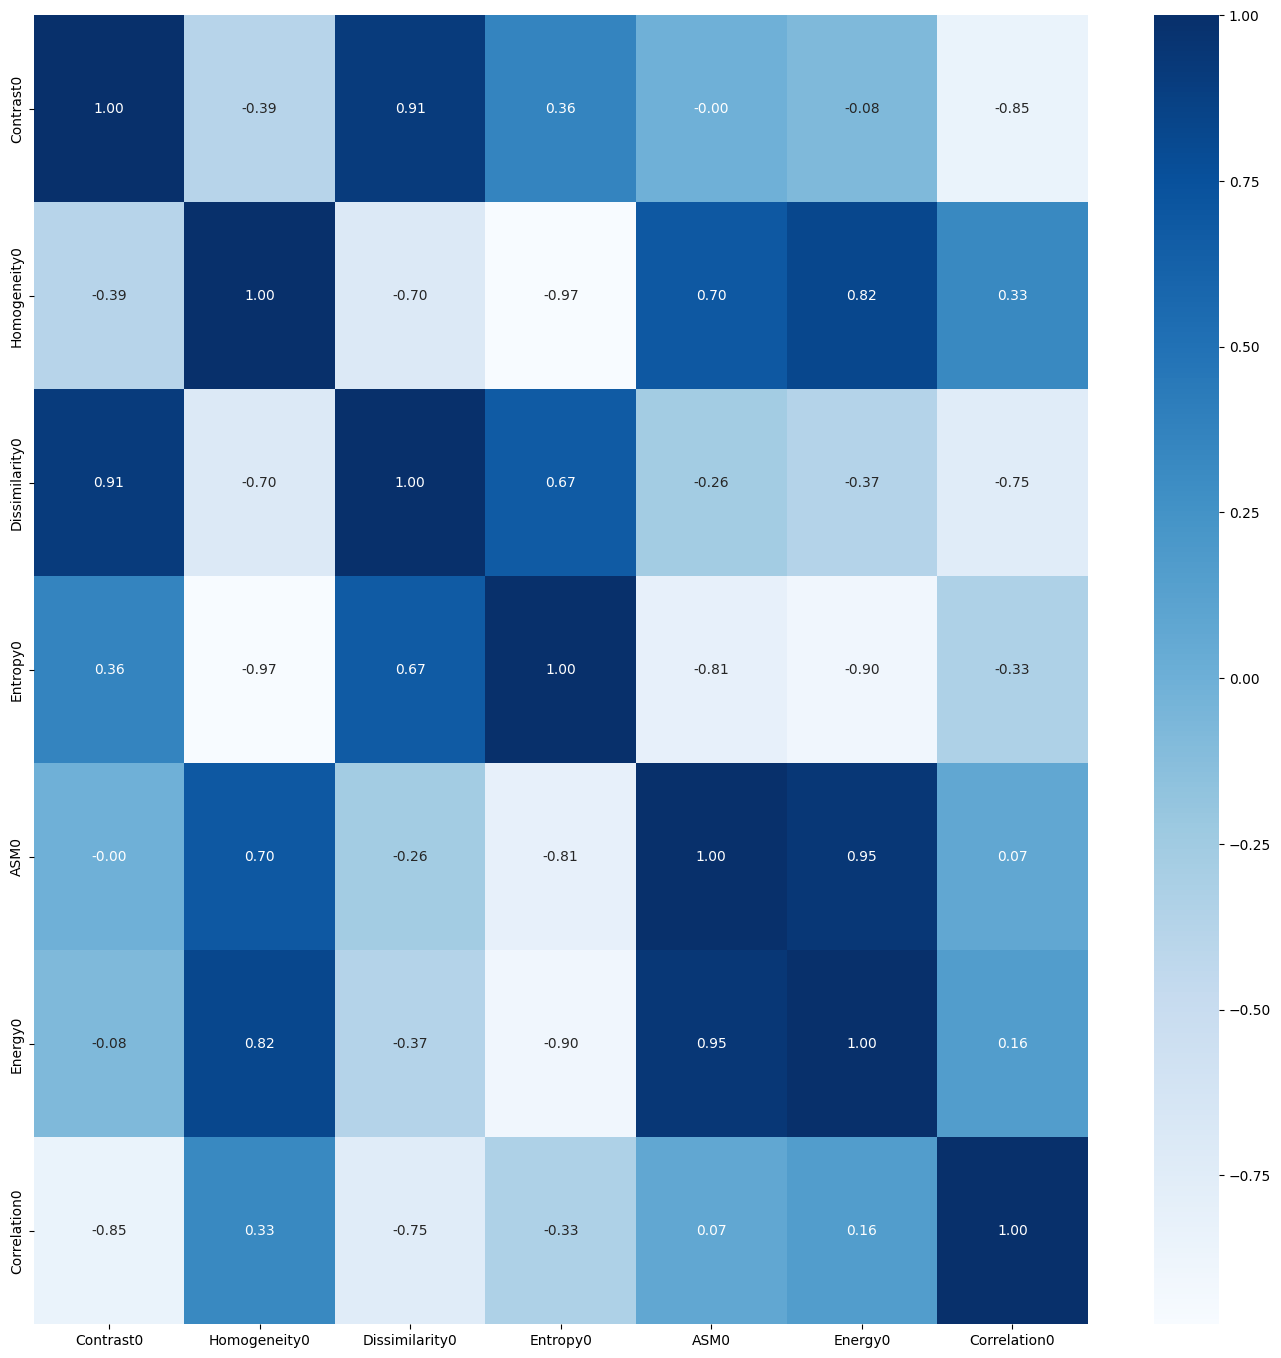

In [21]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Selection Feature Correlation

Visualisasi matriks korelasi berbentuk heatmap ini menunjukkan adanya indikasi multikolinieritas yang sangat ekstrem pada fitur hasil ekstraksi GLCM, di mana sebagian besar fitur sejenis antar-sudut yang berbeda (seperti Contrast_0 hingga Contrast_135) memiliki nilai korelasi yang sangat kuat mendekati angka satu akibat pola tekstur citra MRI otak yang cenderung searah. Meskipun kelompok fitur Homogeneity/Energy dan Contrast/Dissimilarity memiliki hubungan negatif (berbanding terbalik) secara fisis karena kontras yang tinggi pasti menurunkan keseragaman jaringan, penggunaan threshold korelasi sebesar 0.95 dipilih sebagai batas toleransi yang longgar untuk melakukan Seleksi Fitur (Feature Selection). Batas yang tinggi ini berfungsi untuk mempertahankan lebih banyak variasi informasi tekstur mikro asli citra dan hanya mengeliminasi fitur-fitur yang benar-benar "kembar identik" (korelasi $\ge$ 95%), sehingga model Machine Learning (KNN, SVM, dan Random Forest) tetap mendapatkan asupan data ciri yang kaya namun terhindar dari ketergantungan linier yang terlalu sempurna demi menjaga kestabilan akurasi klasifikasi antara kelas glioma dan notumor.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(480, 7)
(120, 7)
(480,)
(120,)


## Splittig Data

Pada bagian ini, dilakukan split data yang dimana dibuat variabel untuk training dan test pada dataset yang telah di ekstraksi fiturnya. Bagian test_size ini digunakan untuk membagi data yang dimana jika nilainya 0,2 berarti 20% data akan digunakan untuk testing. Output yang dihasilkan pada variabel ini yaitu x_train yang memiliki 80% data yang memiliki 7 fitur dan x_test memiliki 20% data yang memiliki 7 fitur. Data ini yang akan digunakan untuk penentuan modeling SVM, KKN, dan Random Forest

In [40]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Data

Kode ini digunakan untuk normalisasi mean-std (Standardisasi atau Z-score normalization) pada fitur-fitur training (X_train) dan testing set (X_test). Normalisasi ini dilakukan dengan mengurangi setiap nilai fitur dengan rata-rata training set (X_train.mean()) dan membaginya dengan standar deviasi training set (X_train.std()). Pentingnya metode ini adalah bahwa rata-rata dan standar deviasi hanya dihitung dari X_train dan kemudian diterapkan ke X_test, sebuah praktik yang mencegah data leakage dan memastikan integritas pengujian model.

In [41]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [46]:

# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       0.99      1.00      0.99       242
     notumor       1.00      0.99      0.99       238

    accuracy                           0.99       480
   macro avg       0.99      0.99      0.99       480
weighted avg       0.99      0.99      0.99       480

[[241   1]
 [  2 236]]
Accuracy: 0.99375

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.87      0.95      0.91        58
     notumor       0.95      0.87      0.91        62

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120

[[55  3]
 [ 8 54]]
Accuracy: 0.9083333333333333


## Model Random Forest

Pada bagian ini, terhapat hasil training dan hasil test. Hasil training terdiri dari 480 sampel, model menunjukkan performa yang sangat tinggi dengan akurasi mencapai 99.375%. Kelas glioma memiliki nilai precision sebesar 0.99 dan recall sebesar 1.00, yang berarti hampir seluruh prediksi untuk kelas ini benar dan hampir tidak ada data glioma yang terlewat. Sementara itu, kelas notumor memiliki precision 1.00 dan recall 0.99, menunjukkan bahwa model sangat jarang salah memprediksi kelas ini. Hal ini diperkuat oleh confusion matrix training set [[241, 1], [2, 236]], yang menunjukkan bahwa dari 242 sampel glioma, hanya 1 sampel yang salah diprediksi sebagai notumor, dan dari 238 sampel notumor, hanya 2 sampel yang salah diklasifikasikan sebagai glioma. Nilai F1-score keduanya berada di angka 0.99, mencerminkan keseimbangan yang sangat baik antara precision dan recall.

Pada data test yang terdiri dari 120 sampel, akurasi model turun menjadi 90.83%. Kelas glioma memiliki precision 0.87 dan recall 0.95, artinya model cukup baik dalam mendeteksi kasus glioma namun ada beberapa prediksi positif yang keliru. Sebaliknya, kelas notumor memiliki precision 0.95 namun recall hanya 0.87, yang berarti ada beberapa kasus notumor yang justru diprediksi sebagai glioma oleh model.
Dari confusion matrix testing set [[55, 3], [8, 54]], terlihat bahwa 3 sampel glioma salah diprediksi sebagai notumor, dan 8 sampel notumor salah diprediksi sebagai glioma. F1-score kedua kelas berada di angka 0.91, yang masih tergolong cukup baik untuk data yang belum pernah dilihat model sebelumnya.

Hasil dari training dan testing ini memiliki selisih sebesar 0.9 atau 9% yang dimana hal ini menunjukkan adanya overfitting dari data. Namun hasil yang didapatkan masih dalam kategorI baik.

In [42]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.90      0.97      0.94       242
     notumor       0.97      0.89      0.93       238

    accuracy                           0.93       480
   macro avg       0.94      0.93      0.93       480
weighted avg       0.94      0.93      0.93       480

[[235   7]
 [ 25 213]]
Accuracy: 0.9333333333333333

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.81      0.97      0.88        58
     notumor       0.96      0.79      0.87        62

    accuracy                           0.88       120
   macro avg       0.89      0.88      0.87       120
weighted avg       0.89      0.88      0.87       120

[[56  2]
 [13 49]]
Accuracy: 0.875


## Model SVM

Pada bagian ini, terhapat hasil training dan hasil test. Hasil training terdiri dari 480 sampel, model menunjukkan performa yang sangat tinggi dengan akurasi mencapai 93.33%. Kelas glioma memiliki nilai precision sebesar 0.90 dan recall sebesar 0.97, yang berarti model sangat baik dalam mendeteksi kasus glioma namun masih ada beberapa prediksi yang kurang tepat. Sementara kelas notumor memiliki precision 0.97 namun recall hanya 0.89, menunjukkan bahwa model cukup berhati-hati dalam memprediksi notumor namun ada beberapa kasus yang terlewat. Hal ini diperkuat oleh confusion matrix training set [[235, 7], [25, 213]], yang menunjukkan bahwa dari 235 sampel glioma, ada 7 sampel yang salah diprediksi sebagai notumor, dan dari 213 sampel notumor, hanya 25 sampel yang salah diklasifikasikan sebagai glioma. Nilai F1-score keduanya berada masing masing di angka 0.94 dan 0.93, mencerminkan keseimbangan yang lumayan baik antara precision dan recall. Namun sudah menunjukkan adanya ketidakseimbangan prediksi antar kelas.

Pada data test yang terdiri dari 120 sampel, akurasi model turun menjadi 87.5%. Kelas glioma memiliki precision 0.81 dan recall mencapai 0.97, artinya model sangat sensitif dalam mendeteksi glioma namun cukup sering memberikan prediksi positif yang salah. Sebaliknya, kelas notumor memiliki precision tinggi sebesar 0.96 tetapi recall hanya 0.79, yang berarti banyak kasus notumor yang justru diprediksi sebagai glioma. Dari confusion matrix testing set [[56, 2], [13, 49]], tercatat 2 sampel glioma yang tidak terdeteksi dan 13 sampel notumor yang salah diklasifikasikan sebagai glioma. Ini merupakan angka yang cukup signifikan mengingat total data uji hanya 120 sampel. F1-score kedua kelas berada di angka 0.87-0.88.

Hasil dari training dan testing ini memiliki selisih akurasi training dan testing SVM hanya sekitar 5.8%, sehingga SVM lebih konsisten dan tidak terlalu overfitting dibandingkan random forest.

In [43]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.92      0.99      0.95       242
     notumor       0.99      0.92      0.95       238

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480

[[239   3]
 [ 20 218]]
Accuracy: 0.9520833333333333

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.86      0.97      0.91        58
     notumor       0.96      0.85      0.91        62

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120

[[56  2]
 [ 9 53]]
Accuracy: 0.9083333333333333


## Model KKN

Pada bagian ini, terhapat hasil training dan hasil test. Hasil training terdiri dari 480 sampel, model menunjukkan performa yang sangat tinggi dengan akurasi mencapai 95.20%. Kelas glioma memiliki precision 0.92 dan recall 0.99, yang menunjukkan bahwa model sangat sensitif dalam mendeteksi kasus glioma dengan hanya sedikit kasus yang terlewat. Sementara kelas notumor memiliki precision 0.99 namun recall 0.92, artinya model sangat jarang salah memprediksi notumor namun ada beberapa kasus notumor yang justru diklasifikasikan sebagai glioma. Hal ini diperkuat oleh confusion matrix training set [[239, 3], [20, 218]], yang menunjukkan bahwa dari 239 sampel glioma, ada 3 sampel yang salah diprediksi sebagai notumor, dan dari 218 sampel notumor, hanya 20 sampel yang salah diklasifikasikan sebagai glioma. Nilai F1-score keduanya berada masing masing di angka 0.95, mencerminkan keseimbangan yang sangat baik antara precision dan recall.

Pada data test yang terdiri dari 120 sampel, akurasi model turun menjadi 90.83%. Kelas glioma memiliki precision 0.86 dan recall mencapai 0.97, artinya model sangat sensitif dalam mendeteksi glioma namun cukup sering memberikan prediksi positif yang salah. Sebaliknya, kelas notumor memiliki precision tinggi sebesar 0.96 tetapi recall hanya 0.85, yang berarti banyak kasus notumor yang justru diprediksi sebagai glioma. Dari confusion matrix testing set [[56, 2], [9, 53]], tercatat 2 sampel glioma yang tidak terdeteksi dan 9 sampel notumor yang salah diklasifikasikan sebagai glioma. Ini merupakan angka yang cukup signifikan mengingat total data uji hanya 120 sampel. F1-score kedua kelas berada di angka 0.91.

Hasil dari training dan testing ini memiliki selisih akurasi training dan testing KKN hanya sekitar 5.6%, sehingga KKN lebih konsisten dan tidak terlalu overfitting dibandingkan random forest dan SVM. Selisih dari KKN dan SVM sangat dekat atau kecil.

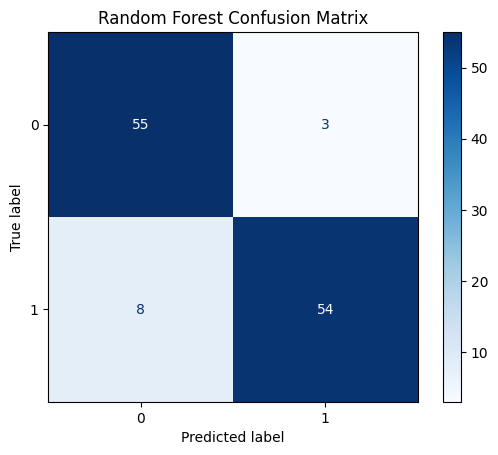

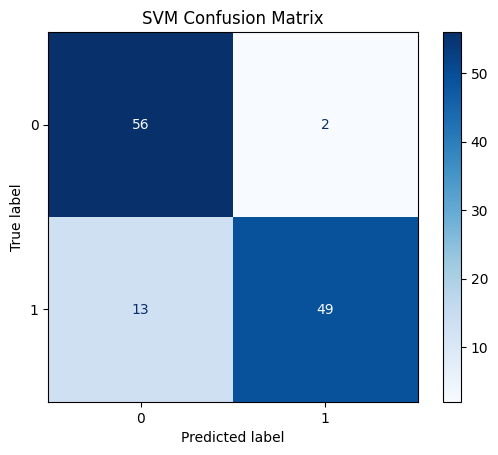

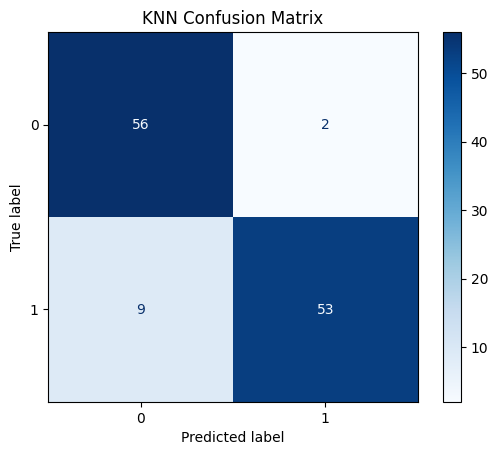

In [47]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## **Evaluasi Confusion Matrix**

Pada bagian ini diperlihatkan hasil confusion matrix dari tiap model(Random Forest, SVM, dan KKN) yang telah digunakan untuk training dan testing data. Pada tabel tersebut terdapat label predicted tabel dan true label. Predicted label menandakan data hasil dari model yang diterapkan dan true label merupakan data asli dari dataset yang digunakan. Angka 0 merupakan representasi data notumor dan 1 merupakan representasi data glioma.

## Kesimpulan

Kesimpulan dari hasil percobaan 2 ini yaitu didapatkan hasil prediksi yang lumayan bagus dari tiap model. Yang dimana hasil nya masih di kisaran 87 hingga 90%. Namun hasil terbaik didapatkan dari model KKN karena akurasi yang didapatkan yaitu 90,83% hampir mendekati 91% yang dimana nilai ini lebih besar dari 2 model yang lain. Model KKN lebih baik dari model lainnya karena karakteristik dataset ini sangat cocok dengan cara kerja KNN. Data yang terkluster baik, ukuran dataset yang kecil, serta tidak adanya asumsi distribusi data membuat KNN mampu bekerja lebih efisien dan konsisten dibandingkan Random Forest maupun SVM pada kasus klasifikasi tumor otak ini.